6


/tmp/ipykernel_5684/3120327607.py:38: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5684/3120327607.py:38: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5684/3120327607.py:38: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5684/3120327607.py:38: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


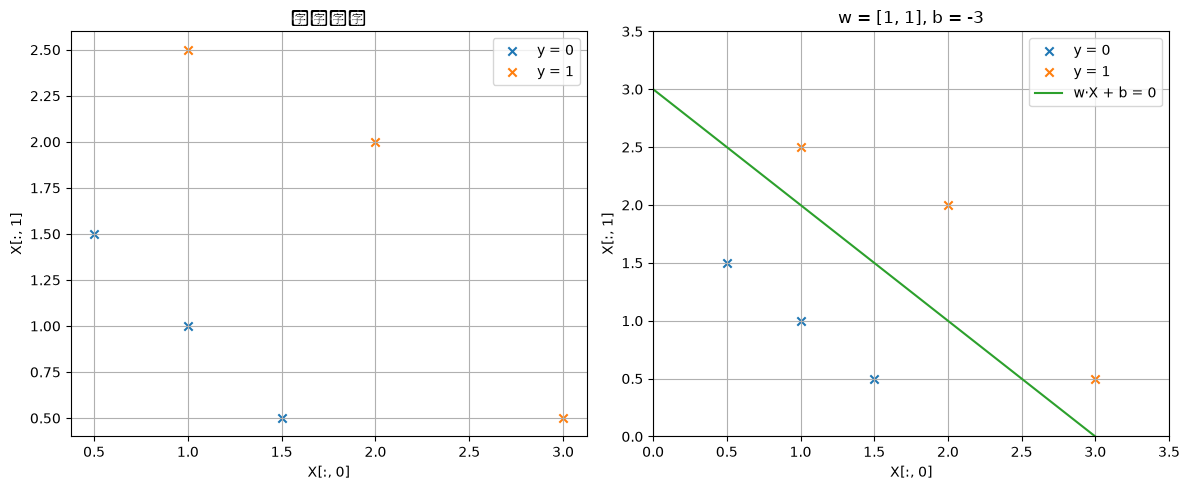

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
def sigmoid(x,w,b):
    f_wb=1/(1+(np.exp(-(w*x+b))))
    return f_wb
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1) 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 原来的散点图
axes[0].scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], color='tab:blue', marker='x', label='y = 0')
axes[0].scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], color='tab:orange', marker='x', label='y = 1')
axes[0].set_xlabel('X[:, 0]')
axes[0].set_ylabel('X[:, 1]')
axes[0].set_title('原始数据')
axes[0].legend()
axes[0].grid(True)

# b = -3 时的决策边界
w = np.array([1, 1])
b = -3
axes[1].scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], color='tab:blue', marker='x', label='y = 0')
axes[1].scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], color='tab:orange', marker='x', label='y = 1')
x1 = np.linspace(0, 3.5, 100)
x2 = -(w[0] * x1 + b) / w[1]
axes[1].plot(x1, x2, color='tab:green', label='w·X + b = 0')
axes[1].set_xlabel('X[:, 0]')
axes[1].set_ylabel('X[:, 1]')
axes[1].set_title('w = [1, 1], b = -3')
axes[1].set_xlim(0, 3.5)
axes[1].set_ylim(0, 3.5)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [18]:
#二元交叉熵函数
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

#二元交叉熵
def binary_cross_entropy(x, y, w, b):
    z = x @ w + b
    # 数值稳定的二元交叉熵
    return np.mean(np.logaddexp(0, z) - y * z)

#梯度下降
def partial(x,y,w,b):
    m,n=x.shape
    dl_dw=np.zeros((n,))
    dl_db=0
    for i in range(m):
        f_wb=1/(1+np.exp(-(np.dot(x[i],w)+b)))
        error=f_wb-y[i]
        for j in range(n):
            dl_dw[j]+=error*x[i,j]
        dl_db+=error
    dl_dw=dl_dw/m
    dl_db=dl_db/m
    return dl_dw,dl_db
            

def gradient_descent(x,y,w_in,b_in,alpha,num_iters,binary_cross_entropy,partial):
    w=copy.deepcopy(w_in)
    b=b_in
    list=[]
    for i in range(num_iters):
        w=w-alpha*partial(x,y,w,b)[0]
        b=b-alpha*partial(x,y,w,b)[1]
        if i<10000:
            list.append(binary_cross_entropy(x,y,w,b))
        if i%100==0:
            print(f"Iteration:{i} Cost:{list[-1]:.4f} w:[{w[0]:.4f},{w[1]:.4f}] b:{b:.4f}")
    return w,b,list

w_in=np.zeros(X.shape[1])
b_in=0
alpha=1.0e-1
num_iters=10000
w_fina,b_fina,list=gradient_descent(X,y,w_in,b_in,alpha,num_iters,binary_cross_entropy,partial)
print(f"经过梯度下降之后的结果 w:{w_fina} b:{b_fina}")


Iteration:0 Cost:0.6846 w:[0.0250,0.0167] b:-0.0015
Iteration:100 Cost:0.5263 w:[0.6106,0.3553] b:-0.9866
Iteration:200 Cost:0.4307 w:[0.9203,0.6471] b:-1.8750
Iteration:300 Cost:0.3606 w:[1.1767,0.9114] b:-2.6341
Iteration:400 Cost:0.3079 w:[1.3992,1.1432] b:-3.2907
Iteration:500 Cost:0.2674 w:[1.5956,1.3471] b:-3.8656
Iteration:600 Cost:0.2355 w:[1.7707,1.5281] b:-4.3746
Iteration:700 Cost:0.2099 w:[1.9283,1.6905] b:-4.8300
Iteration:800 Cost:0.1891 w:[2.0713,1.8373] b:-5.2410
Iteration:900 Cost:0.1717 w:[2.2018,1.9711] b:-5.6150
Iteration:1000 Cost:0.1572 w:[2.3219,2.0938] b:-5.9576
Iteration:1100 Cost:0.1448 w:[2.4329,2.2071] b:-6.2735
Iteration:1200 Cost:0.1342 w:[2.5360,2.3122] b:-6.5663
Iteration:1300 Cost:0.1249 w:[2.6323,2.4101] b:-6.8390
Iteration:1400 Cost:0.1168 w:[2.7225,2.5018] b:-7.0940
Iteration:1500 Cost:0.1097 w:[2.8073,2.5879] b:-7.3335
Iteration:1600 Cost:0.1033 w:[2.8874,2.6691] b:-7.5591
Iteration:1700 Cost:0.0976 w:[2.9631,2.7458] b:-7.7724
Iteration:1800 Cost:0.

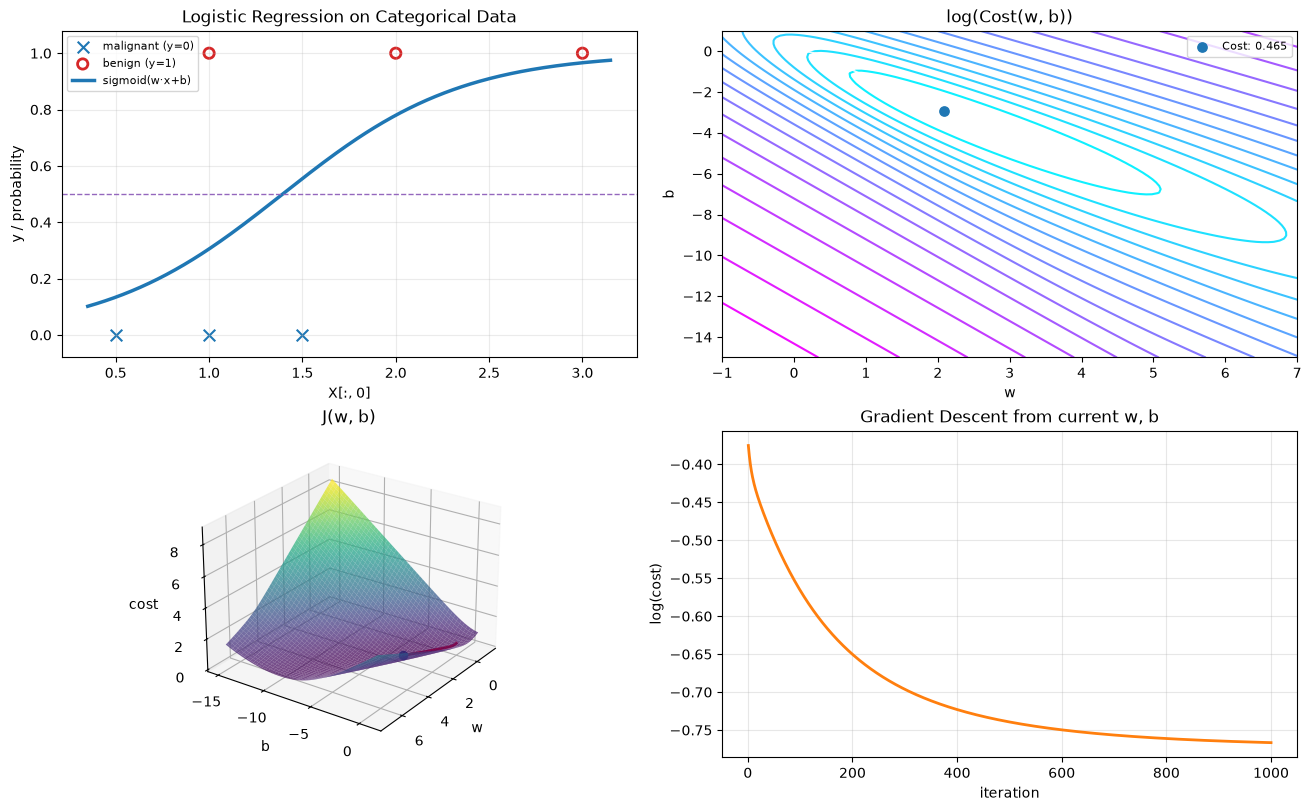

In [19]:
# 将逻辑回归的分类结果、损失等高线、损失曲面和收敛过程画在同一张 2×2 画布中
# 直接复用上一单元定义的 X、y；这里用第 1 个特征作一维可视化。
x_plot = X[:, 0]

def cost_1d(w, b):
    """一维逻辑回归的稳定二元交叉熵。"""
    z = w * x_plot + b
    return np.mean(np.logaddexp(0, z) - y * z)

def grad_1d(w, b):
    p = 1 / (1 + np.exp(-(w * x_plot + b)))
    return np.mean((p - y) * x_plot), np.mean(p - y)

# 记录梯度下降轨迹，供右下图显示。
plot_w, plot_b = 0.0, 0.0
plot_alpha, plot_iters = 0.1, 1000
plot_costs, plot_ws, plot_bs = [], [], []
for _ in range(plot_iters):
    dw, db = grad_1d(plot_w, plot_b)
    plot_w -= plot_alpha * dw
    plot_b -= plot_alpha * db
    plot_costs.append(cost_1d(plot_w, plot_b))
    plot_ws.append(plot_w)
    plot_bs.append(plot_b)

# 计算 (w, b) 网格上的损失，分别用于等高线和三维曲面。
w_grid = np.linspace(-1, 7, 100)
b_grid = np.linspace(-15, 1, 100)
W, B = np.meshgrid(w_grid, b_grid)
J = np.empty_like(W)
for row in range(B.shape[0]):
    for col in range(W.shape[1]):
        J[row, col] = cost_1d(W[row, col], B[row, col])

fig = plt.figure(figsize=(13, 8), constrained_layout=True)
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4)

# 1. 分类数据与最终的 sigmoid 曲线
x_line = np.linspace(x_plot.min() - 0.15, x_plot.max() + 0.15, 300)
ax1.scatter(x_plot[y == 0], y[y == 0], marker='x', s=70, c='tab:blue', label='malignant (y=0)')
ax1.scatter(x_plot[y == 1], y[y == 1], marker='o', s=55, facecolors='none', edgecolors='tab:red', linewidths=2, label='benign (y=1)')
ax1.plot(x_line, 1 / (1 + np.exp(-(plot_w * x_line + plot_b))), color='tab:blue', lw=2.5, label='sigmoid(w·x+b)')
ax1.axhline(0.5, color='tab:purple', ls='--', lw=1)
ax1.set(title='Logistic Regression on Categorical Data', xlabel='X[:, 0]', ylabel='y / probability', ylim=(-0.08, 1.08))
ax1.grid(alpha=0.25)
ax1.legend(fontsize=8, loc='best')

# 2. log(Cost(w, b)) 等高线与当前参数位置
levels = np.linspace(np.log(J.min()), np.log(J.max()), 18)
ax2.contour(W, B, np.log(J), levels=levels, cmap='cool')
ax2.plot(plot_ws, plot_bs, color='white', lw=1.2, alpha=0.9)
ax2.scatter(plot_w, plot_b, s=45, c='tab:blue', zorder=3, label=f'Cost: {plot_costs[-1]:.3f}')
ax2.set(title='log(Cost(w, b))', xlabel='w', ylabel='b')
ax2.legend(fontsize=8, loc='best')

# 3. 三维损失曲面和下降轨迹
surface = ax3.plot_surface(W, B, J, cmap='viridis', alpha=0.72, linewidth=0, antialiased=True)
ax3.plot(plot_ws, plot_bs, plot_costs, color='crimson', lw=2, label='gradient descent')
ax3.scatter(plot_w, plot_b, plot_costs[-1], c='tab:blue', s=35)
ax3.set(title='J(w, b)', xlabel='w', ylabel='b', zlabel='cost')
ax3.view_init(elev=25, azim=35)

# 4. 梯度下降时的对数损失变化
ax4.plot(np.arange(1, plot_iters + 1), np.log(plot_costs), color='tab:orange', lw=2)
ax4.set(title='Gradient Descent from current w, b', xlabel='iteration', ylabel='log(cost)')
ax4.grid(alpha=0.3)

plt.show()
